<a href="https://colab.research.google.com/github/dinujakr/Final-year-project-IEKF-for-rigid-body-tracking/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Simulation and experimental verification of a Intrinsic Extended Kalman filter for rigid body attitude tracking

#Linear Kalman Filter

Testing the linear kalman filter under smooth and rapid rotations using EuroC Datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Load Data sets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# CHANGE THIS to switch between EuRoC MAV sequences
# Easy:   r"F:\Uni\FYP\ES7 3 exam\MH_01_easy"
# Medium: r"F:\Uni\FYP\ES7 3 example\MH_03_medium"
# Hard:   r"F:\Uni\FYP\ES7 3 example\MH_05_difficult"
# Very hard: r"F:\Uni\FYP\ES7 3 example\V2_03_difficult"

DATASET = "/content/drive/MyDrive/FYP/V2_03_difficult"
# ============================================================

imu_path = DATASET + r"/imu0/data.csv"
gt_path  = DATASET + r"/state_groundtruth_estimate0/data.csv"

# Load CSV
imu = pd.read_csv(imu_path)
gt  = pd.read_csv(gt_path)

In [ ]:
t0 = min(imu.iloc[0,0], gt.iloc[0,0])   # same global reference

# IMU Timeline and raw values
t_imu = (imu.iloc[:,0].values - t0) * 1e-9
gyro = imu.iloc[:,1:4].values   # wx, wy, wz
acc  = imu.iloc[:,4:7].values   # ax, ay, az

# GT Timeline
t_gt  = (gt.iloc[:,0].values  - t0) * 1e-9

# Quaternion
q_gt = gt[[' q_RS_w []',' q_RS_x []',' q_RS_y []',' q_RS_z []']].values


# --- CONVERSION & UTILITY FUNCTIONS ---

# Convert accelerometer to Euler angles
def accel_to_euler(acc):
    ax, ay, az = acc
    norm = np.linalg.norm(acc)
    if norm == 0:
        return np.array([0.0, 0.0])
    ax, ay, az = ax/norm, ay/norm, az/norm

    phi = np.arctan2(ay, az)
    theta = np.arctan2(-ax, np.sqrt(ay**2 + az**2))

    return np.array([phi, theta])

# Convert Ground Truth Quaternions to Euler angles
def quat_to_euler(q):
    w, x, y, z = q
    phi = np.arctan2(2 * (w*x + y*z), 1 - 2 * (x*x + y*y))
    sin_pitch = np.clip(2 * (w*y - z*x), -1.0, 1.0)
    theta = np.arcsin(sin_pitch)
    psi = np.arctan2(2 * (w*z + x*y), 1 - 2 * (y*y + z*z))
    return np.array([phi, theta, psi])

# Properly unwrap cumulative angle trajectories to remove ±π wrap jumps
def unwrap_angle(a):
    a_unwrapped = np.copy(a)
    for i in range(1, len(a_unwrapped)):
        diff = a_unwrapped[i] - a_unwrapped[i-1]
        while diff > np.pi:
            a_unwrapped[i] -= 2 * np.pi
            diff -= 2 * np.pi
        while diff < -np.pi:
            a_unwrapped[i] += 2 * np.pi
            diff += 2 * np.pi
    return a_unwrapped


# --- DATA PROCESSING ---

# 1. Compute and unwrap direct sensor orientations from entire Accelerometer log
roll_meas = np.arctan2(acc[:, 1], acc[:, 2])
pitch_meas = np.arctan2(-acc[:, 0], np.sqrt(acc[:, 1]**2 + acc[:, 2]**2))

roll_meas = unwrap_angle(roll_meas)
pitch_meas = unwrap_angle(pitch_meas)

# 2. Extract full Ground Truth Euler angles from quaternions and unwrap them
euler_gt = np.array([quat_to_euler(q) for q in q_gt])
euler_gt[:, 0] = unwrap_angle(euler_gt[:, 0])
euler_gt[:, 1] = unwrap_angle(euler_gt[:, 1])

# 3. Interpolate Ground Truth data perfectly over the IMU sensor timeline
interp_gt_roll  = interp1d(t_gt, euler_gt[:, 0], bounds_error=False, fill_value='extrapolate')
interp_gt_pitch = interp1d(t_gt, euler_gt[:, 1], bounds_error=False, fill_value='extrapolate')

gt_roll_unwrapped  = interp_gt_roll(t_imu)
gt_pitch_unwrapped = interp_gt_pitch(t_imu)

dataset_name = DATASET.split("/")[-1]




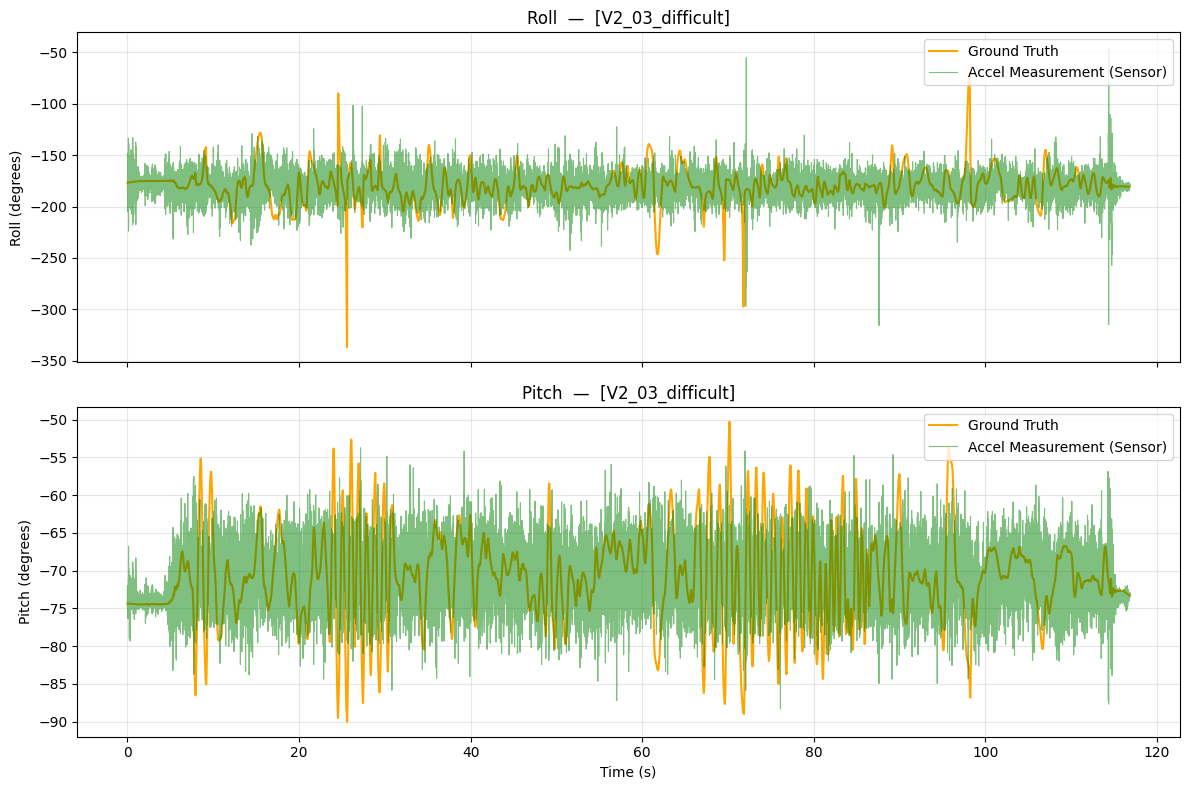

In [ ]:
# --- PLOTTING DATA ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Roll subplot ---
ax1.plot(t_imu, np.degrees(gt_roll_unwrapped), label='Ground Truth', color='orange', linewidth=1.5)
ax1.plot(t_imu, np.degrees(roll_meas), label='Accel Measurement (Sensor)', color='green', alpha=0.5, linewidth=0.8)
ax1.set_ylabel("Roll (degrees)")
ax1.set_title(f"Roll  —  [{dataset_name}]")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Pitch subplot ---
ax2.plot(t_imu, np.degrees(gt_pitch_unwrapped), label='Ground Truth', color='orange', linewidth=1.5)
ax2.plot(t_imu, np.degrees(pitch_meas), label='Accel Measurement (Sensor)', color='green', alpha=0.5, linewidth=0.8)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Pitch (degrees)")
ax2.set_title(f"Pitch  —  [{dataset_name}]")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###Linear system assumption and state estimation by linear kalman filter

$$
\mathbf{x} = \begin{bmatrix} \phi \\ \theta \\ \psi \end{bmatrix}
$$



=== RMSE Report [/content/drive/MyDrive/FYP/V2_03_difficult] ===
  Roll  RMSE : 16.811 degrees
  Pitch RMSE : 6.579 degrees
  Yaw   RMSE : 119.570 degrees



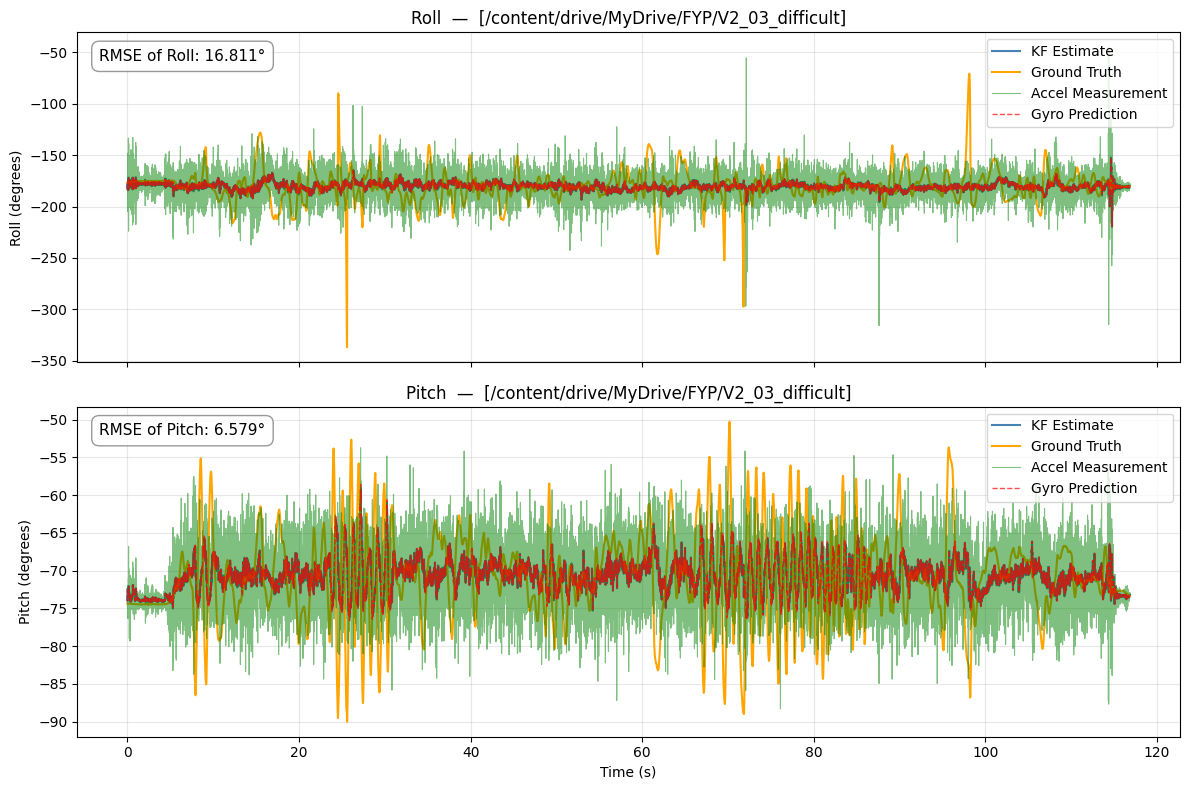

In [ ]:
# IMU
t_imu = (imu.iloc[:,0].values - t0) * 1e-9
gyro = imu.iloc[:,1:4].values   # wx, wy, wz
acc  = imu.iloc[:,4:7].values   # ax, ay, az


# Initialize from first accel measurement
phi0, theta0 = accel_to_euler(acc[0])
x = np.array([phi0, theta0, 0.0])  # [roll, pitch, yaw]

P = np.eye(3) * 0.1

Q = np.eye(3) * 1e-4    # gyro integrates cleanly for short time
R = np.eye(2) * 1e-2    # accel-to-euler is moderately noisy


# Observation matrix
H = np.array([
    [1,0,0],
    [0,1,0]
])

x_est = []
x_pred_list = []   # gyro-only prediction (before KF update)
time_kf = []

for k in range(len(t_imu)-1):

    dt = t_imu[k+1] - t_imu[k]

    wx, wy, wz = gyro[k]

    # 🔹 Prediction (gyro integration only)
    x = x + np.array([wx, wy, wz]) * dt
    P = P + Q                            # covariance grows with process noise
    x_pred_list.append(x.copy())         # save before update

    # 🔹 Measurement (from accel)
    z = accel_to_euler(acc[k])
    z[0] = z[0]
    z[1] = z[1]

    # 🔹 Update
    y = z - H @ x
    y[0] = (y[0] + np.pi) % (2*np.pi) - np.pi   # wrap innovation to [-π, π]
    y[1] = (y[1] + np.pi) % (2*np.pi) - np.pi

    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)

    x = x + K @ y
    x[0] = x[0]
    x[1] = x[1]
    x[2] = x[2]

    P = (np.eye(3) - K @ H) @ P

    x_est.append(x.copy())
    time_kf.append(t_imu[k])

x_est = np.array(x_est)

#take above z values and plot
z1 = np.arctan2(acc[:,1], acc[:,2])
z2 = np.arctan2(-acc[:,0], np.sqrt(acc[:,1]**2 + acc[:,2]**2))

def quat_to_euler(q):
    w,x,y,z = q

    phi = np.arctan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))
    sin_pitch = np.clip(2*(w*y - z*x), -1.0, 1.0)   # clamp to avoid NaN
    theta = np.arcsin(sin_pitch)
    psi = np.arctan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))

    return np.array([phi, theta, psi])

#unwrap euler angles

def unwrap_angle(a):
    for i in range(1, len(a)):
        diff = a[i] - a[i-1]
        while diff > np.pi:
            a[i] -= 2*np.pi
            diff -= 2*np.pi
        while diff < -np.pi:
            a[i] += 2*np.pi
            diff += 2*np.pi
    return a


euler_gt = np.array([quat_to_euler(q) for q in q_gt])

#unwrap euler angles
euler_gt[:,0] = unwrap_angle(euler_gt[:,0])
euler_gt[:,1] = unwrap_angle(euler_gt[:,1])
euler_gt[:,2] = unwrap_angle(euler_gt[:,2])

roll_meas = np.arctan2(acc[:,1], acc[:,2])  # match EKF length
roll_meas = unwrap_angle(roll_meas)               # remove -π/+π wrapping spikes
dataset_name = DATASET.split("\\")[-1]

# Interpolate GT to KF timestamps for fair comparison
from scipy.interpolate import interp1d

time_kf = np.array(time_kf)

def compute_rmse(kf_col, gt_col):
    interp_gt = interp1d(t_gt, gt_col, bounds_error=False, fill_value='extrapolate')
    gt_at_kf  = interp_gt(time_kf)
    diff = kf_col - gt_at_kf
    # wrap angle difference to [-π, π]
    diff = (diff + np.pi) % (2*np.pi) - np.pi
    return np.sqrt(np.mean(diff**2))

rmse_roll  = compute_rmse(x_est[:,0], euler_gt[:,0])
rmse_pitch = compute_rmse(x_est[:,1], euler_gt[:,1])
rmse_yaw   = compute_rmse(x_est[:,2], euler_gt[:,2])

print(f"\n=== RMSE Report [{dataset_name}] ===")
print(f"  Roll  RMSE : {np.degrees(rmse_roll):.3f} degrees")
print(f"  Pitch RMSE : {np.degrees(rmse_pitch):.3f} degrees")
print(f"  Yaw   RMSE : {np.degrees(rmse_yaw):.3f} degrees")
print(f"==========================================\n")

x_pred_arr = np.array(x_pred_list)
# Unwrap estimates and predictions to remove wrap spikes in the plot
x_est[:,0] = unwrap_angle(x_est[:,0])
x_est[:,1] = unwrap_angle(x_est[:,1])
x_est[:,2] = unwrap_angle(x_est[:,2])

x_pred_arr[:,0] = unwrap_angle(x_pred_arr[:,0])
x_pred_arr[:,1] = unwrap_angle(x_pred_arr[:,1])
x_pred_arr[:,2] = unwrap_angle(x_pred_arr[:,2])

# Accelerometer-derived pitch measurement (match KF length)
pitch_meas = np.arctan2(-acc[:-1,0], np.sqrt(acc[:-1,1]**2 + acc[:-1,2]**2))
pitch_meas = unwrap_angle(pitch_meas)
pitch_meas = pitch_meas[:len(time_kf)]

# Interpolate GT to KF timestamps for overlay
interp_gt_roll  = interp1d(t_gt, euler_gt[:, 0], bounds_error=False, fill_value='extrapolate')
interp_gt_pitch = interp1d(t_gt, euler_gt[:, 1], bounds_error=False, fill_value='extrapolate')
gt_roll_at_kf   = interp_gt_roll(time_kf)
gt_pitch_at_kf  = interp_gt_pitch(time_kf)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Roll subplot ---
ax1.plot(time_kf, np.degrees(x_est[:, 0]),       label='KF Estimate',       color='steelblue', linewidth=1.5)
ax1.plot(time_kf, np.degrees(gt_roll_at_kf),     label='Ground Truth',      color='orange',    linewidth=1.5)
ax1.plot(time_kf, np.degrees(roll_meas),          label='Accel Measurement', color='green',     alpha=0.5, linewidth=0.8)
ax1.plot(time_kf, np.degrees(x_pred_arr[:, 0]),   label='Gyro Prediction',   color='red',       linestyle='--', alpha=0.7, linewidth=1)
ax1.set_ylabel("Roll (degrees)")
ax1.set_title(f"Roll  —  [{dataset_name}]")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Print RMSE in the figure
ax1.text(0.02, 0.95, f"RMSE of Roll: {np.degrees(rmse_roll):.3f}°",
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

# --- Pitch subplot ---
ax2.plot(time_kf, np.degrees(x_est[:, 1]),       label='KF Estimate',       color='steelblue', linewidth=1.5)
ax2.plot(time_kf, np.degrees(gt_pitch_at_kf),    label='Ground Truth',      color='orange',    linewidth=1.5)
ax2.plot(time_kf, np.degrees(pitch_meas),         label='Accel Measurement', color='green',     alpha=0.5, linewidth=0.8)
ax2.plot(time_kf, np.degrees(x_pred_arr[:, 1]),   label='Gyro Prediction',   color='red',       linestyle='--', alpha=0.7, linewidth=1)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Pitch (degrees)")
ax2.set_title(f"Pitch  —  [{dataset_name}]")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Print RMSE in the figure
ax2.text(0.02, 0.95, f"RMSE of Pitch: {np.degrees(rmse_pitch):.3f}°",
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

###Non linear system

# EKF for Roll & Pitch Estimation — EuRoC MAV IMU Data

Nonlinear EKF that predicts orientation by integrating the **full Euler-angle body-rate
kinematics** (valid at large angles, unlike the linear KF), and corrects roll/pitch using
accelerometer-derived angles — but **only when the vehicle is near-stationary** (gated update).

---

## 1. State Vector

$$
x = \begin{bmatrix}\phi \\ \theta \\ \psi\end{bmatrix} \quad \text{(roll, pitch, yaw — radians)}
$$

No gyro-bias states in this version — raw gyro rates are used directly in the kinematics.
$\psi$ has **no measurement correction** (no magnetometer); it is integrated open-loop.

---

## 2. Inputs

$$
u = [\omega_x,\ \omega_y,\ \omega_z]^T \quad \text{(raw body-frame gyro rates, rad/s)}
$$

---

## 3. Nonlinear Process Model (continuous-time)

Full ZYX Euler-angle kinematic equations:

$$
\dot\phi = \omega_x + \omega_y\sin\phi\tan\theta + \omega_z\cos\phi\tan\theta
$$

$$
\dot\theta = \omega_y\cos\phi - \omega_z\sin\phi
$$

$$
\dot\psi = \omega_y\frac{\sin\phi}{\cos\theta} + \omega_z\frac{\cos\phi}{\cos\theta}
$$

---

## 4. Discretization (forward Euler)

$$
x_{k+1} = x_k + \dot x_k \,\Delta t, \qquad \Delta t = t_{k+1}-t_k
$$

then each angle is wrapped to $(-\pi,\pi]$.

**Numerical safeguards:**
- $\theta$ clamped to $\left[-\frac{\pi}{2}+0.1,\ \frac{\pi}{2}-0.1\right]$ before evaluating $\tan\theta$ and $1/\cos\theta$ — avoids blow-up near gimbal lock at $\pm90°$ pitch
- $\dot\phi,\dot\theta,\dot\psi$ hard-clamped to $\pm20\ \text{rad/s}$ as a safety bound

---

## 5. State-Transition Jacobian $F$

$$
F = I_3 +
\begin{bmatrix}
0 & (\omega_y\cos\phi-\omega_z\sin\phi)\tan\theta\,\Delta t & 0\\
(-\omega_y\sin\phi-\omega_z\cos\phi)\,\Delta t & 0 & 0\\
0 & 0 & 0
\end{bmatrix}
$$

evaluated at $\phi_{k-1},\theta_{k-1}$ with the current gyro reading. Only the
roll↔pitch cross-coupling terms are linearized — all other partials
(including the $\sec^2\theta$ terms and the $\psi$ row) default to identity.

---

## 6. Process Noise & Covariance Propagation

$$
Q = q_0 I_3, \qquad q_0 = 10^{-4}
$$

$$
P_{k|k-1} = F P_{k-1} F^T + Q
$$

---

## 7. Measurement Model

Accelerometer-derived roll/pitch via the small-angle gravity-alignment formula
(`accel_to_euler`):

$$
z_k = \begin{bmatrix}\operatorname{atan2}(a_y,a_z)\\[2pt] \operatorname{atan2}\!\left(-a_x,\ \sqrt{a_y^2+a_z^2}\right)\end{bmatrix}
$$

$$
H = \begin{bmatrix}1&0&0\\0&1&0\end{bmatrix}, \qquad z_k = H x_k + v_k,\quad v_k\sim\mathcal N(0,R)
$$

$$
R = r_0 I_2, \qquad r_0 = 10^{-2}
$$

---

## 8. Adaptive Gating — Stationarity Check

The accelerometer update runs **only** when specific-force magnitude is close to $g$:

$$
\text{use\_acc}_k = \Big(\,\big|\lVert a_k\rVert - g\big| < 1.0\,\Big), \qquad g = 9.81\ \text{m/s}^2
$$

If false, the measurement for that step is discarded entirely — a hard-threshold
version of "downweight the accelerometer during dynamic acceleration."

---

## 9. EKF Recursion

**Predict (always):**

$$
\hat x_{k|k-1} = f(\hat x_{k-1}, u_k), \qquad P_{k|k-1} = F P_{k-1} F^T + Q
$$

**Update (only if $\text{use\_acc}_k$ is true):**

$$
y_k = \operatorname{wrap}\!\big(z_k - H\hat x_{k|k-1}\big)
$$

$$
S_k = H P_{k|k-1} H^T + R
$$

$$
K_k = P_{k|k-1} H^T S_k^{-1}
$$

$$
\hat x_k = \hat x_{k|k-1} + K_k y_k, \qquad P_k = (I-K_kH)P_{k|k-1}
$$

If false: $\hat x_k = \hat x_{k|k-1}$, $P_k = P_{k|k-1}$ (prediction passed through unchanged).

---

## 10. Note on Yaw

$\dot\phi$ and $\dot\theta$ do **not** depend on $\psi$, and $H$ has no third column —
so $\psi$ neither influences nor receives correction from roll/pitch estimation. It is
carried purely for completeness and RMSE reporting, and is expected to drift
unboundedly — consistent with yaw being unobservable from accelerometer + gyro alone.


=== RMSE Report [/content/drive/MyDrive/FYP/V2_03_difficult] ===
  Roll  RMSE : 16.325 degrees
  Pitch RMSE : 5.818 degrees
  Yaw   RMSE : 102.162 degrees



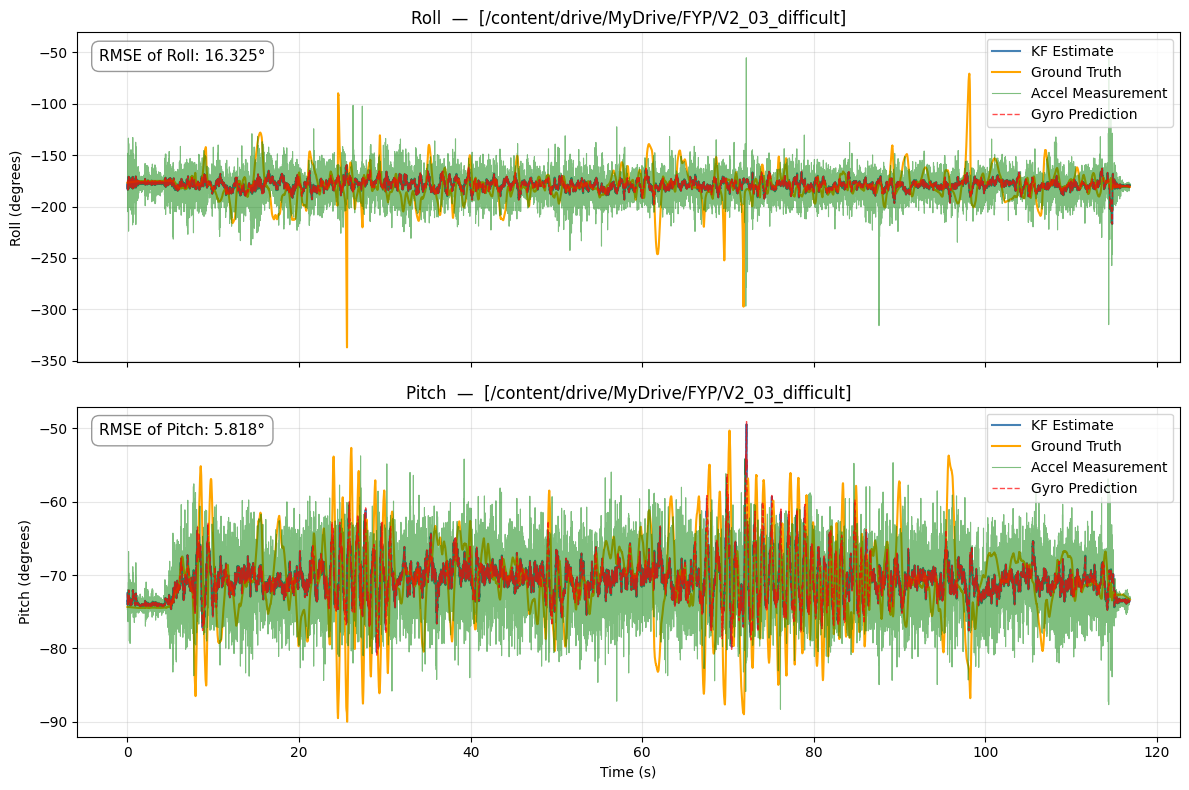

In [ ]:

# Initialize from first accel measurement
phi0, theta0 = accel_to_euler(acc[0])
x = np.array([phi0, theta0, 0.0])  # [roll, pitch, yaw]

P = np.eye(3) * 0.1

Q = np.eye(3) * 1e-4   # gyro integrates cleanly for short time
R = np.eye(2) * 1e-2    # accel-to-euler is moderately noisy


# Observation matrix
H = np.array([
    [1,0,0],
    [0,1,0]
])

x_est = []
x_pred_list = []   # gyro-only prediction (before KF update)
time_kf = []

for k in range(len(t_imu)-1):

    dt = t_imu[k+1] - t_imu[k]

    wx, wy, wz = gyro[k]

    # 🔹 Prediction (gyro integration only)
    phi, theta, psi = x
    wx, wy, wz = gyro[k]

    # --- SAFE ANGLE HANDLING ---
    theta_safe = np.clip(theta, -np.pi/2 + 0.1, np.pi/2 - 0.1)

    tan_theta = np.tan(theta_safe)
    cos_theta = np.cos(theta_safe)
    cos_theta = np.clip(cos_theta, 1e-3, None)

    # --- EULER KINEMATICS ---
    phi_dot = wx + np.sin(phi)*tan_theta*wy + np.cos(phi)*tan_theta*wz
    theta_dot = np.cos(phi)*wy - np.sin(phi)*wz
    psi_dot = (np.sin(phi)/cos_theta)*wy + (np.cos(phi)/cos_theta)*wz

    # --- OPTIONAL SAFETY CLAMP (recommended) ---
    phi_dot   = np.clip(phi_dot,   -20, 20)
    theta_dot = np.clip(theta_dot, -20, 20)
    psi_dot   = np.clip(psi_dot,   -20, 20)

    # --- STATE UPDATE ---
    x = x + np.array([phi_dot, theta_dot, psi_dot]) * dt

    def wrap(a):
        return (a + np.pi) % (2*np.pi) - np.pi

    x[0] = wrap(x[0])
    x[1] = wrap(x[1])
    x[2] = wrap(x[2])

    F = np.eye(3)

    F[0,1] = (np.cos(phi)*np.tan(theta)*wy - np.sin(phi)*np.tan(theta)*wz) * dt
    F[1,0] = (-np.sin(phi)*wy - np.cos(phi)*wz) * dt
    P = F @ P @ F.T + Q                  # covariance grows with process noise
    x_pred_list.append(x.copy())         # save before update

    # 🔹 Measurement (from accel)
    g = 9.81
    a_norm = np.linalg.norm(acc[k])

    if abs(a_norm - g) < 1.0:   # threshold (tune 0.5–2.0)
        use_acc = True
    else:
        use_acc = False

    # 🔹 Update
    if use_acc:
        z = accel_to_euler(acc[k])

        y = z - H @ x
        y[0] = wrap(y[0])
        y[1] = wrap(y[1])

        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)

        x = x + K @ y
        P = (np.eye(3) - K @ H) @ P

    x_est.append(x.copy())
    time_kf.append(t_imu[k])

x_est = np.array(x_est)

#take above z values and plot
z1 = np.arctan2(acc[:,1], acc[:,2])
z2 = np.arctan2(-acc[:,0], np.sqrt(acc[:,1]**2 + acc[:,2]**2))

def quat_to_euler(q):
    w,x,y,z = q

    phi = np.arctan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))
    sin_pitch = np.clip(2*(w*y - z*x), -1.0, 1.0)   # clamp to avoid NaN
    theta = np.arcsin(sin_pitch)
    psi = np.arctan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))

    return np.array([phi, theta, psi])

#unwrap euler angles

def unwrap_angle(a):
    for i in range(1, len(a)):
        diff = a[i] - a[i-1]
        while diff > np.pi:
            a[i] -= 2*np.pi
            diff -= 2*np.pi
        while diff < -np.pi:
            a[i] += 2*np.pi
            diff += 2*np.pi
    return a


euler_gt = np.array([quat_to_euler(q) for q in q_gt])

#unwrap euler angles
euler_gt[:,0] = unwrap_angle(euler_gt[:,0])
euler_gt[:,1] = unwrap_angle(euler_gt[:,1])
euler_gt[:,2] = unwrap_angle(euler_gt[:,2])

roll_meas = np.arctan2(acc[:, 1], acc[:, 2])
roll_meas = unwrap_angle(roll_meas)
roll_meas = roll_meas[:len(time_kf)]
dataset_name = DATASET.split("\\")[-1]

# Interpolate GT to KF timestamps for fair comparison
from scipy.interpolate import interp1d

time_kf = np.array(time_kf)

def compute_rmse(kf_col, gt_col):
    interp_gt = interp1d(t_gt, gt_col, bounds_error=False, fill_value='extrapolate')
    gt_at_kf  = interp_gt(time_kf)
    diff = kf_col - gt_at_kf
    # wrap angle difference to [-π, π]
    diff = (diff + np.pi) % (2*np.pi) - np.pi
    return np.sqrt(np.mean(diff**2))

rmse_roll  = compute_rmse(x_est[:,0], euler_gt[:,0])
rmse_pitch = compute_rmse(x_est[:,1], euler_gt[:,1])
rmse_yaw   = compute_rmse(x_est[:,2], euler_gt[:,2])

print(f"\n=== RMSE Report [{dataset_name}] ===")
print(f"  Roll  RMSE : {np.degrees(rmse_roll):.3f} degrees")
print(f"  Pitch RMSE : {np.degrees(rmse_pitch):.3f} degrees")
print(f"  Yaw   RMSE : {np.degrees(rmse_yaw):.3f} degrees")
print(f"==========================================\n")

x_pred_arr = np.array(x_pred_list)

# Unwrap estimates and predictions to remove wrap spikes in the plot
x_est[:,0] = unwrap_angle(x_est[:,0])
x_est[:,1] = unwrap_angle(x_est[:,1])
x_est[:,2] = unwrap_angle(x_est[:,2])

x_pred_arr[:,0] = unwrap_angle(x_pred_arr[:,0])
x_pred_arr[:,1] = unwrap_angle(x_pred_arr[:,1])
x_pred_arr[:,2] = unwrap_angle(x_pred_arr[:,2])

# Accelerometer-derived pitch measurement (match KF length)
pitch_meas = np.arctan2(-acc[:-1,0], np.sqrt(acc[:-1,1]**2 + acc[:-1,2]**2))
pitch_meas = unwrap_angle(pitch_meas)
pitch_meas = pitch_meas[:len(time_kf)]

# Interpolate GT to KF timestamps for overlay
interp_gt_roll  = interp1d(t_gt, euler_gt[:, 0], bounds_error=False, fill_value='extrapolate')
interp_gt_pitch = interp1d(t_gt, euler_gt[:, 1], bounds_error=False, fill_value='extrapolate')
gt_roll_at_kf   = interp_gt_roll(time_kf)
gt_pitch_at_kf  = interp_gt_pitch(time_kf)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Roll subplot ---
ax1.plot(time_kf, np.degrees(x_est[:, 0]),       label='KF Estimate',       color='steelblue', linewidth=1.5)
ax1.plot(time_kf, np.degrees(gt_roll_at_kf),     label='Ground Truth',      color='orange',    linewidth=1.5)
ax1.plot(time_kf, np.degrees(roll_meas),          label='Accel Measurement', color='green',     alpha=0.5, linewidth=0.8)
ax1.plot(time_kf, np.degrees(x_pred_arr[:, 0]),   label='Gyro Prediction',   color='red',       linestyle='--', alpha=0.7, linewidth=1)
ax1.set_ylabel("Roll (degrees)")
ax1.set_title(f"Roll  —  [{dataset_name}]")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Print RMSE in the figure
ax1.text(0.02, 0.95, f"RMSE of Roll: {np.degrees(rmse_roll):.3f}°",
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

# --- Pitch subplot ---
ax2.plot(time_kf, np.degrees(x_est[:, 1]),       label='KF Estimate',       color='steelblue', linewidth=1.5)
ax2.plot(time_kf, np.degrees(gt_pitch_at_kf),    label='Ground Truth',      color='orange',    linewidth=1.5)
ax2.plot(time_kf, np.degrees(pitch_meas),         label='Accel Measurement', color='green',     alpha=0.5, linewidth=0.8)
ax2.plot(time_kf, np.degrees(x_pred_arr[:, 1]),   label='Gyro Prediction',   color='red',       linestyle='--', alpha=0.7, linewidth=1)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Pitch (degrees)")
ax2.set_title(f"Pitch  —  [{dataset_name}]")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Print RMSE in the figure
ax2.text(0.02, 0.95, f"RMSE of Pitch: {np.degrees(rmse_pitch):.3f}°",
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

Dataset      : /content/drive/MyDrive/FYP/V2_03_difficult
Valid steps  : 22970
Mean error   : 95.0133 deg
Median error : 102.7100 deg
Max error    : 133.1634 deg
RMSE         : 100.2898 deg


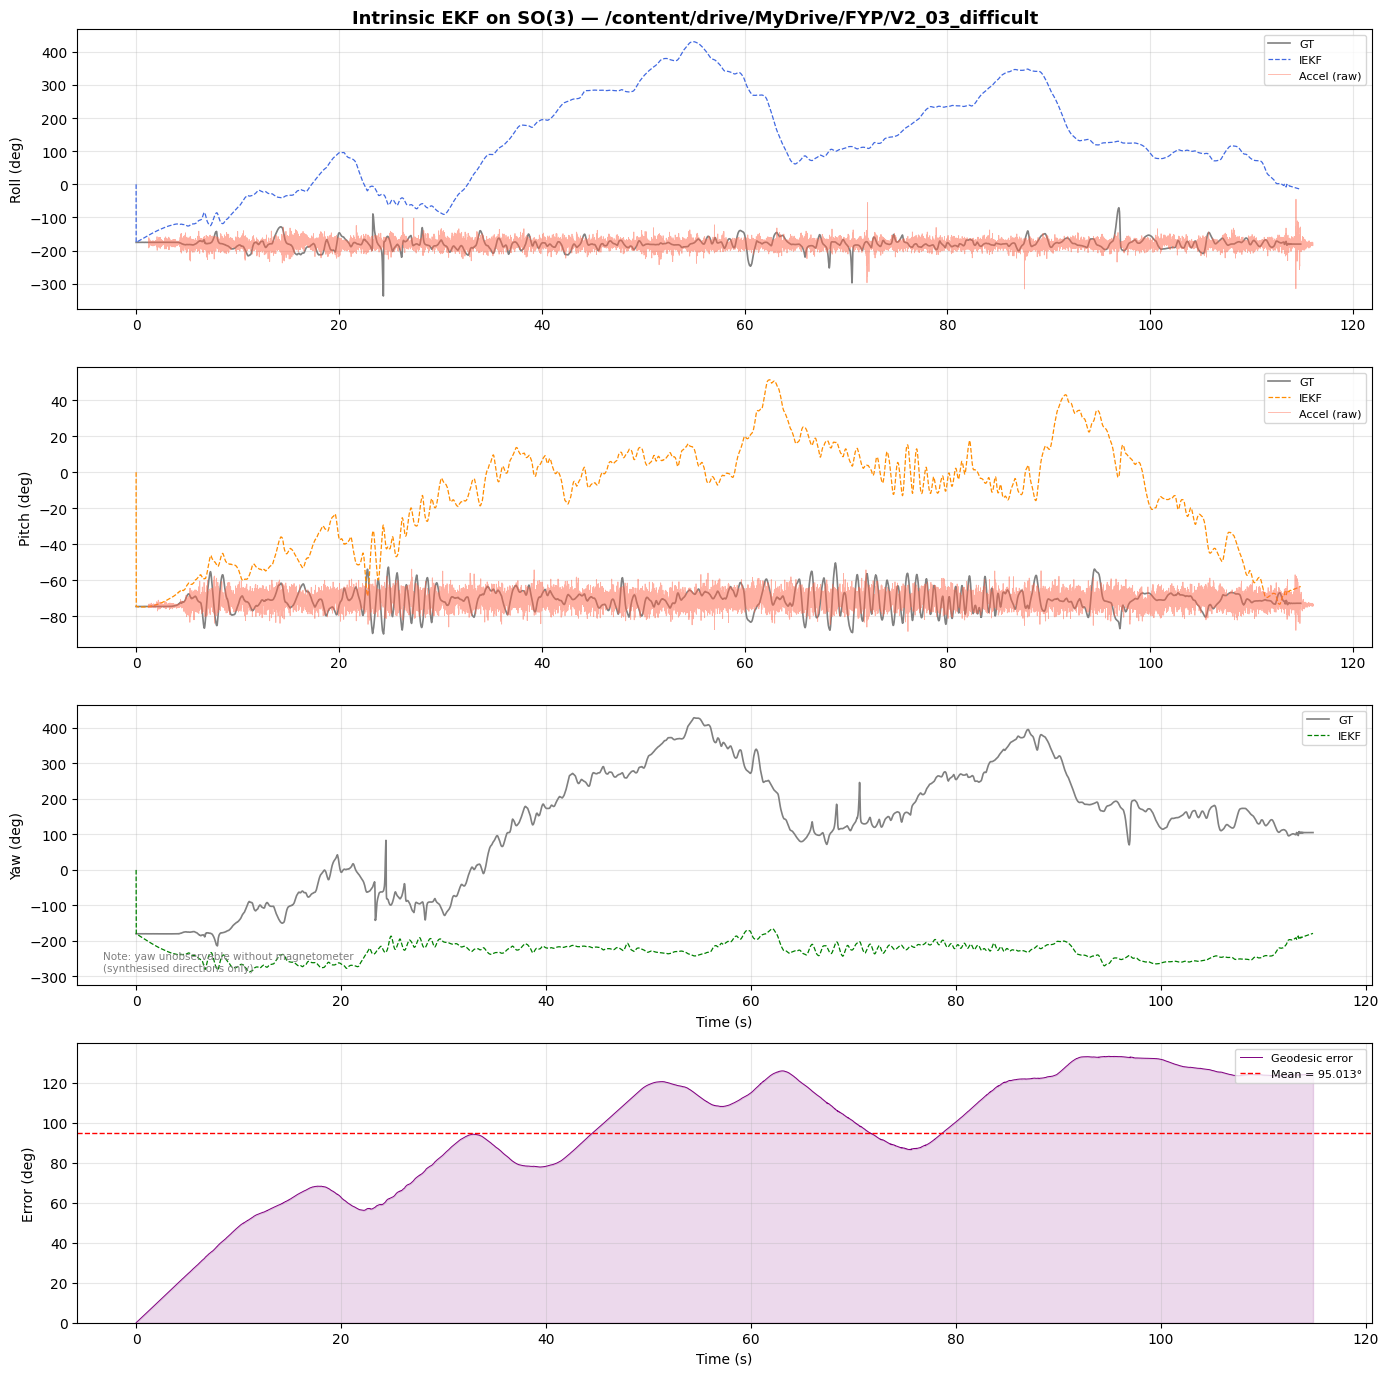

In [11]:

# =============================================================================
# INTRINSIC EKF ON SO(3) — ATTITUDE ESTIMATION
# Continues from the data-loading cell above.
# State: R ∈ SO(3).  Input: gyro ω.  Measurements: 3 body-frame directions.
# Theory: DEKF from RigidBodyIntinsicEKF_DHSM.ipynb (eqs. 55–59).
# =============================================================================

# ── SO(3) primitives ──────────────────────────────────────────────────────────

def hat(v):
    """R^3 → so(3) skew-symmetric matrix."""
    return np.array([[ 0,    -v[2],  v[1]],
                     [ v[2],  0,    -v[0]],
                     [-v[1],  v[0],  0   ]], dtype=float)

def exp_SO3(phi):
    """Rodrigues: R^3 → SO(3),  exp(hat(phi))."""
    angle = np.linalg.norm(phi)
    if angle < 1e-10:
        return np.eye(3) + hat(phi)
    K = hat(phi / angle)
    return np.eye(3) + np.sin(angle)*K + (1 - np.cos(angle))*(K @ K)

def log_SO3(R):
    """SO(3) → R^3,  principal rotation vector."""
    c = float(np.clip((np.trace(R) - 1.0)*0.5, -1.0, 1.0))
    angle = np.arccos(c)
    if angle < 1e-10:
        return np.zeros(3)
    return (angle / (2.0*np.sin(angle))) * np.array(
        [R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]])

def quat_to_R(w, x, y, z):
    """Unit quaternion (w,x,y,z) → 3×3 rotation matrix."""
    return np.array([
        [1-2*(y*y+z*z),   2*(x*y-w*z),   2*(x*z+w*y)],
        [  2*(x*y+w*z), 1-2*(x*x+z*z),   2*(y*z-w*x)],
        [  2*(x*z-w*y),   2*(y*z+w*x), 1-2*(x*x+y*y)],
    ])

def nearest_SO3(M):
    """Project matrix onto SO(3) via SVD (corrects numerical drift)."""
    U, _, Vt = np.linalg.svd(M)
    return U @ np.diag([1., 1., np.linalg.det(U @ Vt)]) @ Vt

def Phi_SO3(phi):
    """
    Φ(φ) = ad_φ e^{ad_φ} / (e^{ad_φ} − I)  on so(3).
    Closed form: I + (1−cosθ)/θ² [φ]× + (θ−sinθ)/θ³ [φ]×²
    Used to shape the process noise matrix G_{k−1}.
    """
    th = np.linalg.norm(phi)
    K  = hat(phi)
    if th < 1e-8:
        return np.eye(3) + 0.5*K
    return (np.eye(3)
            + ((1 - np.cos(th)) / th**2) * K
            + ((th - np.sin(th)) / th**3) * (K @ K))

def R_to_euler_zyx(R):
    """Extract roll, pitch, yaw (ZYX / RPY) from rotation matrix."""
    pitch = np.arctan2(-R[2,0], np.sqrt(R[2,1]**2 + R[2,2]**2))
    roll  = np.arctan2(R[2,1], R[2,2])
    yaw   = np.arctan2(R[1,0], R[0,0])
    return roll, pitch, yaw


# ── Measurement model ─────────────────────────────────────────────────────────

def compute_H(R_minus):
    """
    Measurement Jacobian H_k ∈ R^{9×3}.
    For each reference direction eᵢ: ∂(R̃⁻ᵀ eᵢ)/∂η = −hat(R̃⁻ᵀ eᵢ)
    Stack three (3×3) blocks → (9×3).
    """
    e = np.eye(3)
    return np.vstack([-hat(R_minus.T @ e[i]) for i in range(3)])

def compute_innovation(R_minus, A1, A2, A3):
    """
    Tangent-space innovation ν ∈ R^9.
    νᵢ = ŷᵢ × Aᵢ,  where ŷᵢ = R̃⁻ᵀ eᵢ.
    """
    e = np.eye(3)
    return np.hstack([
        np.cross(R_minus.T @ e[i], A)
        for i, A in enumerate([A1, A2, A3])
    ]).reshape(-1, 1)

def synthesise_directions(R_true, sigma_dir, rng):
    """
    Simulate three noisy body-frame direction measurements.
    Aᵢ ≈ R_true^T eᵢ + noise,  renormalised to S².
    (Replicates notebook sensor() — EuRoC has no physical vector sensor.)
    """
    e = np.eye(3)
    out = []
    for i in range(3):
        a = R_true.T @ e[i] + rng.normal(0., sigma_dir, 3)
        a /= max(np.linalg.norm(a), 1e-12)
        out.append(a)
    return out


# ── Build ground-truth rotation matrices from quaternions ─────────────────────

R_gt_all = np.array([quat_to_R(*q) for q in q_gt])   # (N_gt, 3, 3)


# ── Interpolate GT rotation onto IMU timestamps ───────────────────────────────
# We slerp between adjacent GT samples at each IMU step.

from scipy.spatial.transform import Rotation, Slerp

key_rots = Rotation.from_matrix(R_gt_all)
slerp    = Slerp(t_gt, key_rots)

# Only interpolate within GT time range
mask_valid = (t_imu >= t_gt[0]) & (t_imu <= t_gt[-1])
t_imu_valid = t_imu[mask_valid]

R_gt_imu = slerp(t_imu_valid).as_matrix()   # (N_valid, 3, 3) — GT at IMU times
gyro_valid = gyro[mask_valid]
N_valid    = len(t_imu_valid)


# ── IEKF filter parameters ────────────────────────────────────────────────────

SIGMA_GYRO = 5e-3       # gyro noise std (rad/s)
SIGMA_DIR  = 2e-2       # simulated direction-sensor noise std (rad)

Sigma_q = SIGMA_GYRO**2 * np.eye(3)    # process noise covariance (3×3)
Sigma_m = SIGMA_DIR**2  * np.eye(9)    # measurement noise covariance (9×9)

rng = np.random.default_rng(0)


# ── DEKF main loop (eqs. 55–59) ───────────────────────────────────────────────

# Initialise from first GT sample in the valid window
idx0    = np.argmax(mask_valid)
R_est   = R_gt_imu[0].copy()
P       = 1e-4 * np.eye(3)

roll_iekf  = np.zeros(N_valid)
pitch_iekf = np.zeros(N_valid)
yaw_iekf   = np.zeros(N_valid)
err_deg    = np.zeros(N_valid)

for k in range(N_valid - 1):
    dt = t_imu_valid[k+1] - t_imu_valid[k]
    if dt <= 0 or dt > 0.1:
        continue

    omega = gyro_valid[k]

    # ── Prediction (eq. 55, 57) ──────────────────────────────────────────
    R_minus  = R_est @ exp_SO3(dt * omega)
    G        = dt * R_est @ Phi_SO3(-dt * omega)
    P_minus  = P + G @ Sigma_q @ G.T

    # ── Synthesise direction measurements from GT ─────────────────────────
    R_true   = R_gt_imu[k+1]
    A1, A2, A3 = synthesise_directions(R_true, SIGMA_DIR, rng)

    # ── Innovation & Jacobian (eq. 58) ───────────────────────────────────
    nu = compute_innovation(R_minus, A1, A2, A3)   # (9,1)
    H  = compute_H(R_minus)                         # (9,3)
    S  = H @ P_minus @ H.T + Sigma_m               # (9,9)
    K  = P_minus @ H.T @ np.linalg.inv(S)          # (3,9)

    # ── Update (eq. 56, 59) ──────────────────────────────────────────────
    correction = (dt * K @ nu).ravel()
    R_est = exp_SO3(correction) @ R_minus
    P     = (np.eye(3) - K @ H) @ P_minus

    # SO(3) reprojection every 50 steps
    if k % 50 == 0:
        R_est = nearest_SO3(R_est)

    # ── Record ───────────────────────────────────────────────────────────
    r, p, y = R_to_euler_zyx(R_est)
    roll_iekf[k+1]  = r
    pitch_iekf[k+1] = p
    yaw_iekf[k+1]   = y

    dR  = R_est.T @ R_true
    err_deg[k+1] = np.degrees(np.linalg.norm(log_SO3(dR)))

# Unwrap IEKF Euler angles for clean plots
roll_iekf  = unwrap_angle(roll_iekf)
pitch_iekf = unwrap_angle(pitch_iekf)
yaw_iekf   = unwrap_angle(yaw_iekf)

# GT Euler on the valid IMU timeline
roll_gt_valid  = np.array([R_to_euler_zyx(R)[0] for R in R_gt_imu])
pitch_gt_valid = np.array([R_to_euler_zyx(R)[1] for R in R_gt_imu])
yaw_gt_valid   = np.array([R_to_euler_zyx(R)[2] for R in R_gt_imu])
roll_gt_valid  = unwrap_angle(roll_gt_valid)
pitch_gt_valid = unwrap_angle(pitch_gt_valid)
yaw_gt_valid   = unwrap_angle(yaw_gt_valid)

print(f"Dataset      : {dataset_name}")
print(f"Valid steps  : {N_valid}")
print(f"Mean error   : {np.mean(err_deg[1:]):.4f} deg")
print(f"Median error : {np.median(err_deg[1:]):.4f} deg")
print(f"Max error    : {np.max(err_deg[1:]):.4f} deg")
print(f"RMSE         : {np.sqrt(np.mean(err_deg[1:]**2)):.4f} deg")


# ── Plots ─────────────────────────────────────────────────────────────────────

t_plot = t_imu_valid - t_imu_valid[0]   # seconds from start

# Re-calculate full-length raw accelerometer measurements for plotting
# The original roll_meas and pitch_meas might have been truncated by previous cells.
roll_meas_full = np.arctan2(acc[:, 1], acc[:, 2])
pitch_meas_full = np.arctan2(-acc[:, 0], np.sqrt(acc[:, 1]**2 + acc[:, 2]**2))

# Unwrap the raw measurements, using the unwrap_angle function defined earlier
roll_meas_full = unwrap_angle(roll_meas_full)
pitch_meas_full = unwrap_angle(pitch_meas_full)


fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle(f"Intrinsic EKF on SO(3) — {dataset_name}", fontsize=13, fontweight='bold')

# ── Roll ──
ax = axes[0]
ax.plot(t_plot, np.degrees(roll_gt_valid),  color='grey',      lw=1.2, label='GT')
ax.plot(t_plot, np.degrees(roll_iekf),      color='royalblue', lw=0.9, linestyle='--', label='IEKF')
ax.plot(t_imu[mask_valid], np.degrees(roll_meas_full[mask_valid]),
        color='tomato', lw=0.6, alpha=0.5, label='Accel (raw)')
ax.set_ylabel('Roll (deg)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# ── Pitch ──
ax = axes[1]
ax.plot(t_plot, np.degrees(pitch_gt_valid),  color='grey',      lw=1.2, label='GT')
ax.plot(t_plot, np.degrees(pitch_iekf),      color='darkorange', lw=0.9, linestyle='--', label='IEKF')
ax.plot(t_imu[mask_valid], np.degrees(pitch_meas_full[mask_valid]),
        color='tomato', lw=0.6, alpha=0.5, label='Accel (raw)')
ax.set_ylabel('Pitch (deg)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# ── Yaw ──
ax = axes[2]
ax.plot(t_plot, np.degrees(yaw_gt_valid),  color='grey',  lw=1.2, label='GT')
ax.plot(t_plot, np.degrees(yaw_iekf),      color='green', lw=0.9, linestyle='--', label='IEKF')
ax.set_ylabel('Yaw (deg)')
ax.set_xlabel('Time (s)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.annotate('Note: yaw unobservable without magnetometer\n(synthesised directions only)',
            xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7.5, color='gray')

# ── Geodesic error ──
ax = axes[3]
ax.plot(t_plot[1:], err_deg[1:], color='purple', lw=0.7, label='Geodesic error')
ax.axhline(np.mean(err_deg[1:]), color='red', lw=1.0, linestyle='--',
           label=f'Mean = {np.mean(err_deg[1:]):.3f}°')
ax.fill_between(t_plot[1:], err_deg[1:], alpha=0.15, color='purple')
ax.set_ylabel('Error (deg)')
ax.set_xlabel('Time (s)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()
